In [81]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [82]:
car_d = pd.read_csv('/content/car_age_price.csv')

In [83]:
car_d.head()

,Year,Price
0,2018,465000
1,2019,755000
2,2019,700000
3,2018,465000
4,2018,465000


In [84]:
car_d.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype
---  ------  --------------  -----
 0   Year    112 non-null    int64
 1   Price   112 non-null    int64
dtypes: int64(2)
memory usage: 1.9 KB


In [85]:
car_d['Price'].unique()

array([465000, 755000, 700000, 350000, 425000, 575000, 509999, 500000,
       600000, 475000, 550000, 434999, 650000, 450000, 486000, 545000,
       525000, 396000, 325000, 345000, 341000, 490000, 540000, 595000,
       495000, 400000, 300000, 320000, 409999, 390000, 480000, 520000,
       640000, 375000, 420000])

In [86]:
car_d['Year'].unique()

array([2018, 2019, 2015, 2016, 2017, 2020, 2013, 2014])

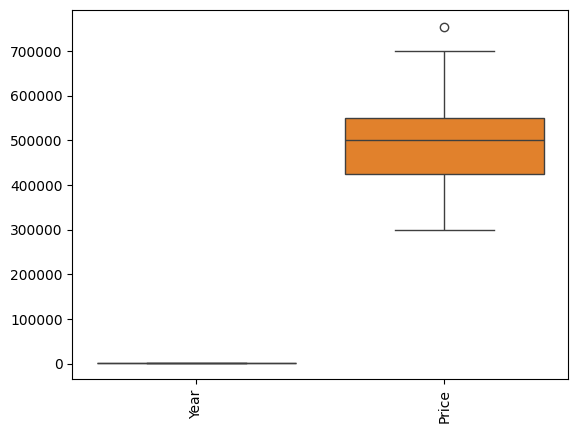

In [87]:
sns.boxplot(car_d)
plt.xticks(rotation=90)
plt.show()

#Using linear regression

In [88]:
# seperate x and y
x = car_d.drop(['Price'], axis = 1)
y = car_d['Price']

In [89]:
# train - test split
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test = train_test_split(x,y,test_size= 0.3, random_state=42)

In [90]:
#creating linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [91]:
#creating linear regression model
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [92]:
model = lr.fit(x_train,y_train)

In [93]:
y_pred = model.predict(x_test)

In [94]:
y_pred

array([598895.38633195, 505711.87168759, 552303.62900977, 552303.62900977,
       552303.62900977, 412528.35704324, 505711.87168759, 552303.62900977,
       598895.38633195, 598895.38633195, 319344.8423989 , 505711.87168759,
       412528.35704324, 645487.14365412, 552303.62900977, 598895.38633195,
       319344.8423989 , 412528.35704324, 505711.87168759, 505711.87168759,
       505711.87168759, 505711.87168759, 505711.87168759, 505711.87168759,
       505711.87168759, 505711.87168759, 412528.35704324, 412528.35704324,
       365936.59972107, 412528.35704324, 505711.87168759, 598895.38633195,
       552303.62900977, 505711.87168759])

In [107]:
from sklearn.metrics import mean_squared_error,r2_score
mse_lr = (mean_squared_error(y_test,y_pred))
r2_lr =(r2_score(y_test,y_pred))
print(mse_lr)
print(r2_lr)

3962573261.894448
0.4887760028600123


In [96]:
price_predict = model.predict(pd.DataFrame([[2014]], columns=['Year']))
price_predict

array([365936.59972107])

#Using lasso regression

In [97]:
# seperate x1 and y1
a1 = car_d.drop(['Price'], axis = 1)
b1 = car_d['Price']

In [98]:
# train - test split
from sklearn.model_selection import train_test_split
x_train1,x_test1,y_train1,y_test1 = train_test_split(x1,y1,test_size= 0.2, random_state=42)

In [99]:
#creating lasso regression model
from sklearn.linear_model import Lasso

In [102]:
lasso = Lasso(alpha=0.1,max_iter=1000)
lasso.fit(x_train1, y_train1)

Lasso(alpha=0.1)

In [103]:
y_pred1 = lasso.predict(x_test1)

In [104]:
from sklearn.metrics import mean_squared_error,r2_score
mse_lasso = (mean_squared_error(y_test1,y_pred1))
r2_lasso = (r2_score(y_test1,y_pred1))
print(mse_lasso)
print(r2_lasso)

4326901608.19506
0.36759381368868127


In [105]:
price_predict_1 = lasso.predict(pd.DataFrame([[2014]], columns=['Year']))
price_predict_1

array([362733.17907993])

In [108]:
comparison_data = pd.DataFrame({
    'Metric': ['Mean Squared Error', 'R2 Score',],
    'Linear Regression': [mse_lr, r2_lr],
    'Lasso Regression': [mse_lasso, r2_lasso]
})
print(comparison_data)

               Metric  Linear Regression  Lasso Regression
0  Mean Squared Error       3.962573e+09      4.326902e+09
1            R2 Score       4.887760e-01      3.675938e-01
